# 03 — Sand Detection (15/05/2026)

Détection automatique du passage dans le bac à sable, **2 méthodes en parallèle** :

- **A) PCA** : calibration sur les CRF des 3 essais d'un participant → axe couloir + bornes percentiles
- **B) Bbox absolue** : test point-in-rectangle avec `BAC_SAND_CORNERS_MM` (coords mesurées 07/05)

## Plan

- **03a** — PCA : calibration + détection + validation vs CRF sur 38 essais
- **03b** — Bbox : détection directe + validation vs CRF sur 38 essais
- **03c** — Comparaison PCA vs Bbox : tableau + plots side-by-side

## Inputs

- 38 essais .npz (post 02e despike)
- Clés utilisées : `raw_Dos01`, `raw_Dos02`, `raw_Dos03`, `raw_Dos04` (XY absolus pour bbox)

In [1]:
from resilience import paths, participants, config
from resilience.io import writer
from resilience.processing import detection
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

## Chargement de tous les essais exploitables

In [2]:
def load_all_trials():
    """Charge tous les essais non-exclus en mémoire (XY + temps)."""
    trials = {}
    for code, P in participants.PARTICIPANTS.items():
        for cond, trial in P.trials.items():
            if trial.excluded:
                continue
            try:
                d = writer.load_processed(code, cond)
            except FileNotFoundError:
                print(f"  ⚠️  Pas de .npz pour {code}/{cond}")
                continue
            # Sacrum XY = barycentre Dos01-04 en XY (absolu, pas centré)
            dos_xy = np.stack([d[f'raw_Dos{i:02d}'][:, :2] for i in range(1, 5)], axis=0)
            sacrum_xy = np.nanmean(dos_xy, axis=0)
            # Interpolation NaN
            for ax in range(2):
                col = sacrum_xy[:, ax]
                if np.isnan(col).any():
                    idx = np.arange(len(col))
                    valid = ~np.isnan(col)
                    if valid.sum() >= 2:
                        col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
                    sacrum_xy[:, ax] = col
            trials[(code, cond)] = {
                'sacrum_xy': sacrum_xy,
                'crf_entry': trial.crf_entry_s if trial.crf_entry_s is not None else np.nan,
                'crf_exit':  trial.crf_exit_s  if trial.crf_exit_s  is not None else np.nan,
                'crop_start_s': trial.crop_start_s,
                'crop_end_s':   trial.crop_end_s,
                'note': trial.note,
            }
    return trials

TRIALS = load_all_trials()
print(f"\n✅ {len(TRIALS)} essais chargés")
print(f"   par participant :")
from collections import Counter
by_p = Counter(code for (code, _) in TRIALS.keys())
for code in sorted(by_p.keys()):
    print(f"     {code} : {by_p[code]} essais")

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_20788\3884858983.py:15: RuntimeWarning: Mean of empty slice
  sacrum_xy = np.nanmean(dos_xy, axis=0)



✅ 38 essais chargés
   par participant :
     001CrMa : 3 essais
     002CrPa : 3 essais
     003BrLu : 3 essais
     004CaGe : 3 essais
     005DeJe : 2 essais
     006MoCa : 3 essais
     007MoMa : 1 essais
     008RiMo : 2 essais
     009DeFr : 3 essais
     010DeYv : 3 essais
     011RiJo : 3 essais
     012WaCh : 3 essais
     013WaJe : 3 essais
     014DeAn : 3 essais


## 03a — Détection PCA

Pipeline :
1. Pour chaque participant : `calibrate_for_participant()` sur ses essais
2. Pour chaque essai : `detect_sand_transition()` → entry/exit
3. `validate_vs_crf()` pour les erreurs

In [3]:
results_pca = []
calibrations_pca = {}

# Group trials par participant
by_participant = {}
for (code, cond), data in TRIALS.items():
    by_participant.setdefault(code, {})[cond] = data['sacrum_xy']

# Calibrer + détecter
for code, sacrum_dict in by_participant.items():
    try:
        calib = detection.calibrate_for_participant(sacrum_dict, code)
        calibrations_pca[code] = calib
    except ValueError as e:
        print(f"  ⚠️  {code} : {e}")
        continue

    for cond, sac in sacrum_dict.items():
        trial_data = TRIALS[(code, cond)]
        det = detection.detect_sand_transition(
            sac,
            center=calib['center'],
            axis_main=calib['axis_main'],
            axis_perp=calib['axis_perp'],
            s_min=calib['s_min'],
            s_max=calib['s_max'],
            d_max=calib['d_max'],
        )
        # Recalage post-crop → référentiel brut (même que CRF)
        offset = trial_data['crop_start_s'] if trial_data['crop_start_s'] is not None else 0.0
        det['entry_t'] = det['entry_t'] + offset if not np.isnan(det['entry_t']) else np.nan
        det['exit_t']  = det['exit_t']  + offset if not np.isnan(det['exit_t'])  else np.nan
        val = detection.validate_vs_crf(det, trial_data['crf_entry'], trial_data['crf_exit'])
        results_pca.append({
            'participant': code,
            'condition':   cond,
            'entry_pca':   det['entry_t'],
            'exit_pca':    det['exit_t'],
            'crf_entry':   trial_data['crf_entry'],
            'crf_exit':    trial_data['crf_exit'],
            'err_entry_s': val['err_entry_s'],
            'err_exit_s':  val['err_exit_s'],
            'dur_pca':     val['duration_auto'],
            'dur_crf':     val['duration_crf'],
            'n_segments':  det['n_segments'],
        })
        # On garde l'objet det complet pour le plot ensuite
        TRIALS[(code, cond)]['det_pca'] = det

df_pca = pd.DataFrame(results_pca)
print(f"\n✅ PCA : {len(df_pca)} essais détectés")
df_pca

  ⚠️  006MoCa : CRF manquante pour 006MoCa/beatmove_adaptatif. Compléter participants.py.

✅ PCA : 35 essais détectés


,participant,condition,entry_pca,exit_pca,crf_entry,crf_exit,err_entry_s,err_exit_s,dur_pca,dur_crf,n_segments
0,001CrMa,silence,293.9875,308.1150,254.00,263.00,39.9875,45.1150,14.1275,9.00,33
1,001CrMa,tempo_random,174.0750,187.4825,248.00,253.00,-73.9250,-65.5175,13.4075,5.00,42
2,001CrMa,beatmove_adaptatif,252.0825,266.7225,253.00,257.00,-0.9175,9.7225,14.6400,4.00,19
3,002CrPa,silence,248.6425,261.1950,277.00,282.00,-28.3575,-20.8050,12.5525,5.00,21
4,002CrPa,beatmove_adaptatif,191.1425,204.2700,243.00,248.00,-51.8575,-43.7300,13.1275,5.00,19
5,002CrPa,tempo_random,189.9725,203.4675,242.00,247.00,-52.0275,-43.5325,13.4950,5.00,19
6,003BrLu,silence,445.5425,451.5275,235.42,239.27,210.1225,212.2575,5.9850,3.85,45
7,003BrLu,tempo_random,309.4700,315.3900,251.22,254.75,58.2500,60.6400,5.9200,3.53,38
8,003BrLu,beatmove_adaptatif,241.3150,252.8750,238.00,244.00,3.3150,8.8750,11.5600,6.00,48
9,004CaGe,silence,357.5900,428.1150,254.50,258.27,103.0900,169.8450,70.5250,3.77,17


In [4]:
# Stats erreurs PCA vs CRF
print("Erreurs PCA vs CRF (s) :")
print(df_pca[['err_entry_s', 'err_exit_s']].describe().round(2))
print()
print(f"Essais avec |err_entry| > 2s : {(df_pca['err_entry_s'].abs() > 2).sum()}")
print(f"Essais avec |err_exit|  > 2s : {(df_pca['err_exit_s'].abs() > 2).sum()}")
print(f"Essais avec n_segments > 1   : {(df_pca['n_segments'] > 1).sum()}")

Erreurs PCA vs CRF (s) :
       err_entry_s  err_exit_s
count        35.00       35.00
mean         19.23       31.06
std          92.39       92.62
min        -206.01     -148.54
25%         -22.23      -16.01
50%           2.00        6.73
75%          58.27       62.54
max         210.12      212.26

Essais avec |err_entry| > 2s : 30
Essais avec |err_exit|  > 2s : 34
Essais avec n_segments > 1   : 35


## 03b — Détection Bbox

Pipeline :
1. Pour chaque essai : `detect_sand_by_bbox()` direct (pas de calibration nécessaire)
2. Marge = `config.BAC_SAND_MARGIN_MM` (100mm par défaut)
3. `validate_vs_crf()` pour les erreurs

In [5]:
results_bbox = []

for (code, cond), data in TRIALS.items():
    det = detection.detect_sand_by_bbox(data['sacrum_xy'])
    # Recalage post-crop → référentiel brut (même que CRF)
    offset = data['crop_start_s'] if data['crop_start_s'] is not None else 0.0
    det['entry_t'] = det['entry_t'] + offset if not np.isnan(det['entry_t']) else np.nan
    det['exit_t']  = det['exit_t']  + offset if not np.isnan(det['exit_t'])  else np.nan
    val = detection.validate_vs_crf(det, data['crf_entry'], data['crf_exit'])
    results_bbox.append({
        'participant': code,
        'condition':   cond,
        'entry_bbox':  det['entry_t'],
        'exit_bbox':   det['exit_t'],
        'crf_entry':   data['crf_entry'],
        'crf_exit':    data['crf_exit'],
        'err_entry_s': val['err_entry_s'],
        'err_exit_s':  val['err_exit_s'],
        'dur_bbox':    val['duration_auto'],
        'dur_crf':     val['duration_crf'],
        'n_segments':  det['n_segments'],
    })
    TRIALS[(code, cond)]['det_bbox'] = det

df_bbox = pd.DataFrame(results_bbox)
print(f"\n✅ Bbox : {len(df_bbox)} essais détectés")
df_bbox


✅ Bbox : 38 essais détectés


,participant,condition,entry_bbox,exit_bbox,crf_entry,crf_exit,err_entry_s,err_exit_s,dur_bbox,dur_crf,n_segments
0,001CrMa,silence,258.4950,263.3550,254.00,263.00,4.4950,0.3550,4.8600,9.00,1
1,001CrMa,tempo_random,248.6075,252.9575,248.00,253.00,0.6075,-0.0425,4.3500,5.00,1
2,001CrMa,beatmove_adaptatif,253.3625,257.5400,253.00,257.00,0.3625,0.5400,4.1775,4.00,1
3,002CrPa,silence,277.4250,282.3850,277.00,282.00,0.4250,0.3850,4.9600,5.00,1
4,002CrPa,beatmove_adaptatif,243.6000,248.5275,243.00,248.00,0.6000,0.5275,4.9275,5.00,1
5,002CrPa,tempo_random,242.7775,247.7275,242.00,247.00,0.7775,0.7275,4.9500,5.00,1
6,003BrLu,silence,235.1400,239.1100,235.42,239.27,-0.2800,-0.1600,3.9700,3.85,1
7,003BrLu,tempo_random,250.8125,254.6575,251.22,254.75,-0.4075,-0.0925,3.8450,3.53,1
8,003BrLu,beatmove_adaptatif,240.8300,244.7375,238.00,244.00,2.8300,0.7375,3.9075,6.00,1
9,004CaGe,silence,254.0975,258.0300,254.50,258.27,-0.4025,-0.2400,3.9325,3.77,1


In [6]:
# Stats erreurs Bbox vs CRF
print("Erreurs Bbox vs CRF (s) :")
print(df_bbox[['err_entry_s', 'err_exit_s']].describe().round(2))
print()
print(f"Essais avec |err_entry| > 2s : {(df_bbox['err_entry_s'].abs() > 2).sum()}")
print(f"Essais avec |err_exit|  > 2s : {(df_bbox['err_exit_s'].abs() > 2).sum()}")
print(f"Essais avec n_segments > 1   : {(df_bbox['n_segments'] > 1).sum()}")

Erreurs Bbox vs CRF (s) :
       err_entry_s  err_exit_s
count        37.00       37.00
mean          0.17       -0.36
std           1.61        2.36
min          -2.96      -13.78
25%          -0.41       -0.18
50%          -0.19        0.06
75%           0.36        0.36
max           6.99        0.94

Essais avec |err_entry| > 2s : 4
Essais avec |err_exit|  > 2s : 2
Essais avec n_segments > 1   : 0


## 03c — Comparaison PCA vs Bbox

Tableau side-by-side + plots.

In [7]:
# Merge des 2 dfs
df_cmp = df_pca[['participant', 'condition', 'crf_entry', 'crf_exit',
                   'entry_pca', 'exit_pca', 'dur_pca']].merge(
    df_bbox[['participant', 'condition', 'entry_bbox', 'exit_bbox', 'dur_bbox']],
    on=['participant', 'condition'])
df_cmp['dur_crf'] = df_cmp['crf_exit'] - df_cmp['crf_entry']
df_cmp['err_pca_entry']  = df_cmp['entry_pca']  - df_cmp['crf_entry']
df_cmp['err_bbox_entry'] = df_cmp['entry_bbox'] - df_cmp['crf_entry']
df_cmp['err_pca_exit']   = df_cmp['exit_pca']   - df_cmp['crf_exit']
df_cmp['err_bbox_exit']  = df_cmp['exit_bbox']  - df_cmp['crf_exit']

# Round pour lisibilité
for c in df_cmp.columns:
    if df_cmp[c].dtype == float:
        df_cmp[c] = df_cmp[c].round(2)

df_cmp

,participant,condition,crf_entry,crf_exit,entry_pca,exit_pca,dur_pca,entry_bbox,exit_bbox,dur_bbox,dur_crf,err_pca_entry,err_bbox_entry,err_pca_exit,err_bbox_exit
0,001CrMa,silence,254.00,263.00,293.99,308.12,14.13,258.50,263.36,4.86,9.00,39.99,4.50,45.12,0.36
1,001CrMa,tempo_random,248.00,253.00,174.08,187.48,13.41,248.61,252.96,4.35,5.00,-73.93,0.61,-65.52,-0.04
2,001CrMa,beatmove_adaptatif,253.00,257.00,252.08,266.72,14.64,253.36,257.54,4.18,4.00,-0.92,0.36,9.72,0.54
3,002CrPa,silence,277.00,282.00,248.64,261.20,12.55,277.42,282.38,4.96,5.00,-28.36,0.43,-20.81,0.38
4,002CrPa,beatmove_adaptatif,243.00,248.00,191.14,204.27,13.13,243.60,248.53,4.93,5.00,-51.86,0.60,-43.73,0.53
5,002CrPa,tempo_random,242.00,247.00,189.97,203.47,13.50,242.78,247.73,4.95,5.00,-52.03,0.78,-43.53,0.73
6,003BrLu,silence,235.42,239.27,445.54,451.53,5.98,235.14,239.11,3.97,3.85,210.12,-0.28,212.26,-0.16
7,003BrLu,tempo_random,251.22,254.75,309.47,315.39,5.92,250.81,254.66,3.84,3.53,58.25,-0.41,60.64,-0.09
8,003BrLu,beatmove_adaptatif,238.00,244.00,241.32,252.88,11.56,240.83,244.74,3.91,6.00,3.31,2.83,8.88,0.74
9,004CaGe,silence,254.50,258.27,357.59,428.12,70.53,254.10,258.03,3.93,3.77,103.09,-0.40,169.85,-0.24


In [8]:
# Stats comparatives
print("Comparaison erreurs PCA vs Bbox :\n")
stats = pd.DataFrame({
    'PCA  entry': df_cmp['err_pca_entry'].abs().describe(),
    'Bbox entry': df_cmp['err_bbox_entry'].abs().describe(),
    'PCA  exit':  df_cmp['err_pca_exit'].abs().describe(),
    'Bbox exit':  df_cmp['err_bbox_exit'].abs().describe(),
}).round(2)
print(stats)

print(f"\n|erreur| > 2s :")
print(f"  PCA  entry : {(df_cmp['err_pca_entry'].abs() > 2).sum()}/{len(df_cmp)}")
print(f"  Bbox entry : {(df_cmp['err_bbox_entry'].abs() > 2).sum()}/{len(df_cmp)}")
print(f"  PCA  exit  : {(df_cmp['err_pca_exit'].abs() > 2).sum()}/{len(df_cmp)}")
print(f"  Bbox exit  : {(df_cmp['err_bbox_exit'].abs() > 2).sum()}/{len(df_cmp)}")

Comparaison erreurs PCA vs Bbox :

       PCA  entry  Bbox entry  PCA  exit  Bbox exit
count       35.00       35.00      35.00      35.00
mean        66.10        0.87      68.71       0.74
std         66.47        1.42      68.65       2.33
min          0.92        0.01       0.81       0.01
25%          9.73        0.24       9.30       0.11
50%         46.49        0.41      45.12       0.22
75%        101.20        0.65     115.47       0.38
max        210.12        6.99     212.26      13.78

|erreur| > 2s :
  PCA  entry : 30/35
  Bbox entry : 4/35
  PCA  exit  : 34/35
  Bbox exit  : 2/35


### Boxplot des erreurs vs CRF

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_20788\2531385483.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df_cmp['err_pca_entry'].dropna(),
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_20788\2531385483.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_cmp['err_pca_exit'].dropna(),


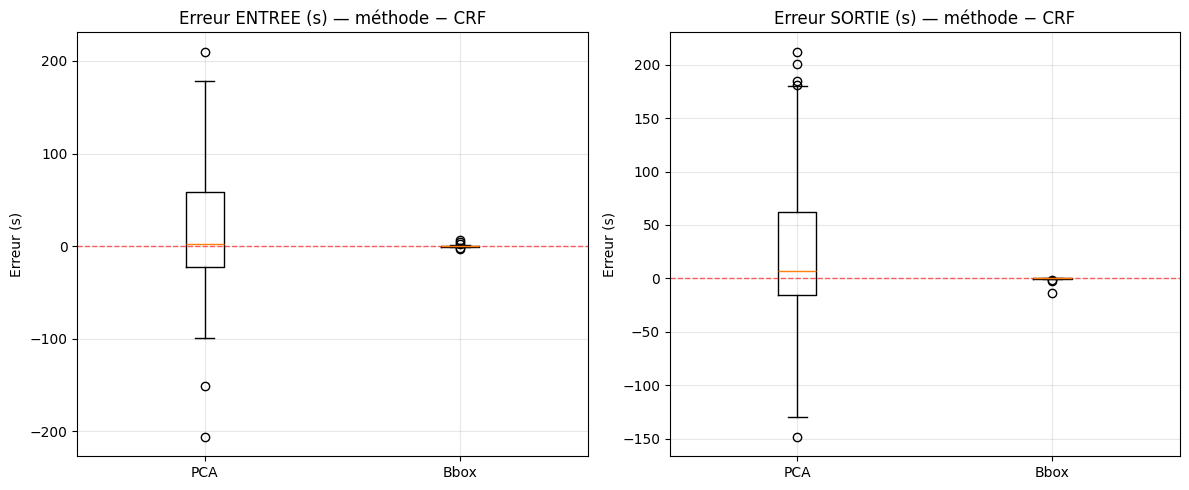

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([df_cmp['err_pca_entry'].dropna(),
                  df_cmp['err_bbox_entry'].dropna()],
                 labels=['PCA', 'Bbox'])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_title('Erreur ENTREE (s) — méthode − CRF')
axes[0].set_ylabel('Erreur (s)')
axes[0].grid(alpha=0.3)

axes[1].boxplot([df_cmp['err_pca_exit'].dropna(),
                  df_cmp['err_bbox_exit'].dropna()],
                 labels=['PCA', 'Bbox'])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('Erreur SORTIE (s) — méthode − CRF')
axes[1].set_ylabel('Erreur (s)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03c_boxplot_errors.png', dpi=80, bbox_inches='tight')
plt.show()

### Vue XY : trajectoire sacrum + bac + couloir PCA

On choisit 6 essais représentatifs (2 par condition) pour visualiser.

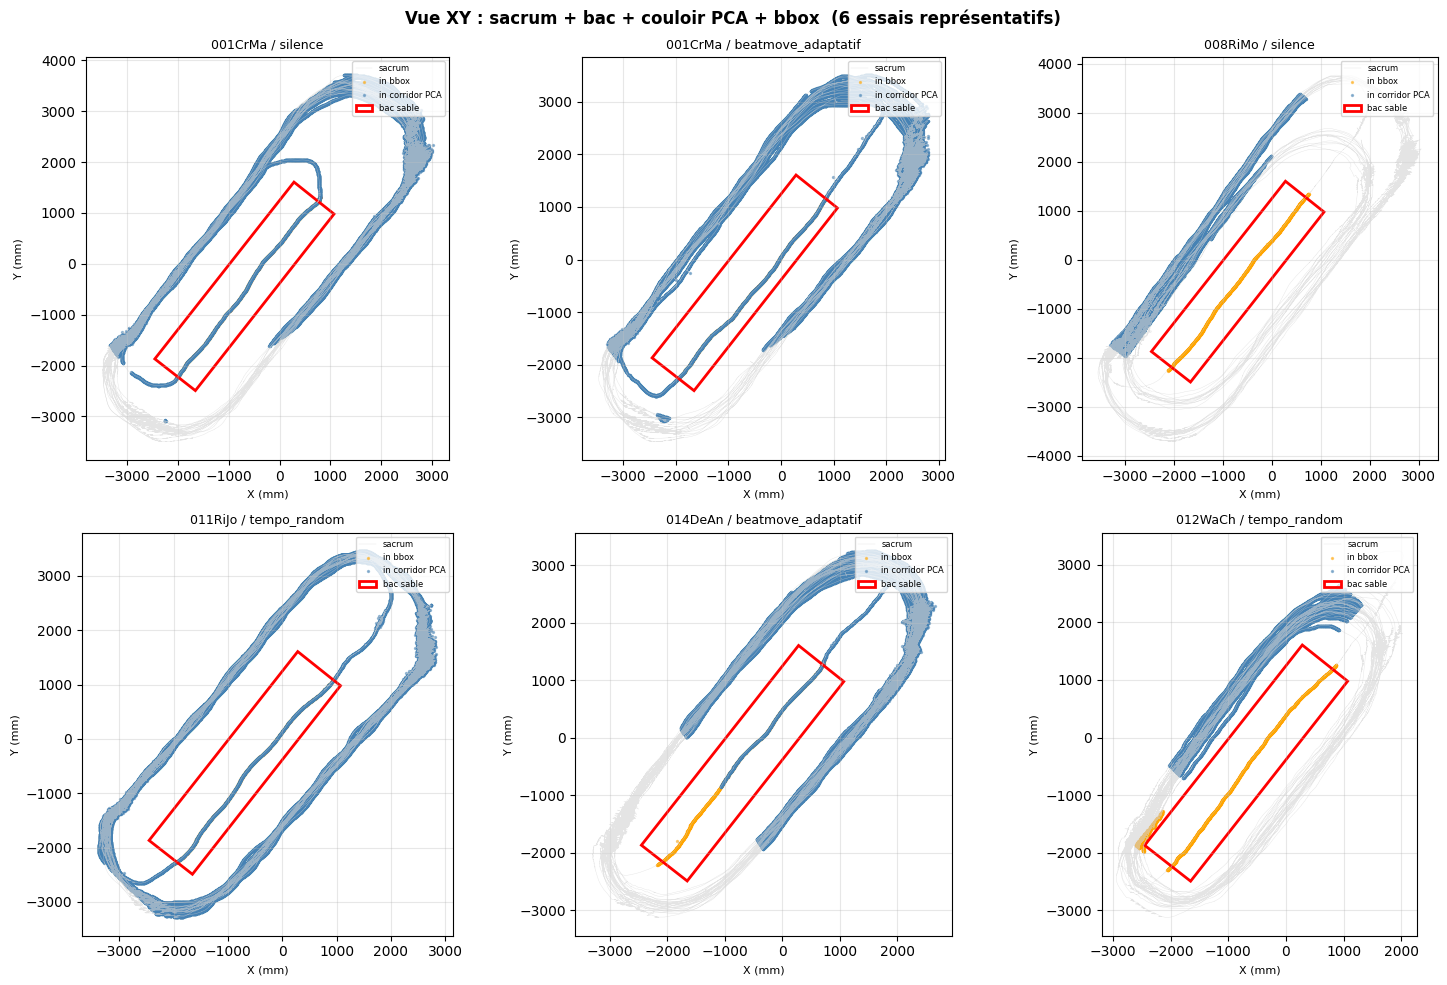

In [10]:
def plot_xy_trial(code, cond, ax):
    """Plot XY : trajectoire sacrum + bac + couloir PCA + zones détectées."""
    data = TRIALS[(code, cond)]
    xy   = data['sacrum_xy']
    det_pca  = data['det_pca']
    det_bbox = data['det_bbox']

    # Trajectoire sacrum complète
    ax.plot(xy[:, 0], xy[:, 1], color='lightgray', linewidth=0.3, alpha=0.6, label='sacrum')

    # Trajectoire dans bbox
    in_bbox = det_bbox['in_bbox']
    if in_bbox.any():
        ax.scatter(xy[in_bbox, 0], xy[in_bbox, 1], s=2, color='orange', alpha=0.5, label='in bbox')

    # Trajectoire dans couloir PCA
    in_corr = det_pca['in_corridor']
    if in_corr.any():
        ax.scatter(xy[in_corr, 0], xy[in_corr, 1], s=2, color='steelblue', alpha=0.5, label='in corridor PCA')

    # Rectangle du bac
    C = config.BAC_SAND_CORNERS_MM
    rect = Polygon([C['A'], C['B'], C['C'], C['D']],
                    closed=True, fill=False, edgecolor='red', linewidth=2, label='bac sable')
    ax.add_patch(rect)

    ax.set_aspect('equal')
    ax.set_title(f'{code} / {cond}', fontsize=9)
    ax.set_xlabel('X (mm)', fontsize=8)
    ax.set_ylabel('Y (mm)', fontsize=8)
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(alpha=0.3)


# 6 essais représentatifs : 2 par condition
examples = [
    ('001CrMa', 'silence'),
    ('001CrMa', 'beatmove_adaptatif'),
    ('008RiMo', 'silence'),
    ('011RiJo', 'tempo_random'),
    ('014DeAn', 'beatmove_adaptatif'),
    ('012WaCh', 'tempo_random'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (code, cond) in zip(axes.flat, examples):
    if (code, cond) in TRIALS:
        plot_xy_trial(code, cond, ax)
    else:
        ax.set_title(f'{code}/{cond} : N/A', fontsize=9)
        ax.axis('off')

plt.suptitle('Vue XY : sacrum + bac + couloir PCA + bbox  (6 essais représentatifs)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('03c_xy_views.png', dpi=80, bbox_inches='tight')
plt.show()

### Timelines : entry/exit selon les 2 méthodes vs CRF

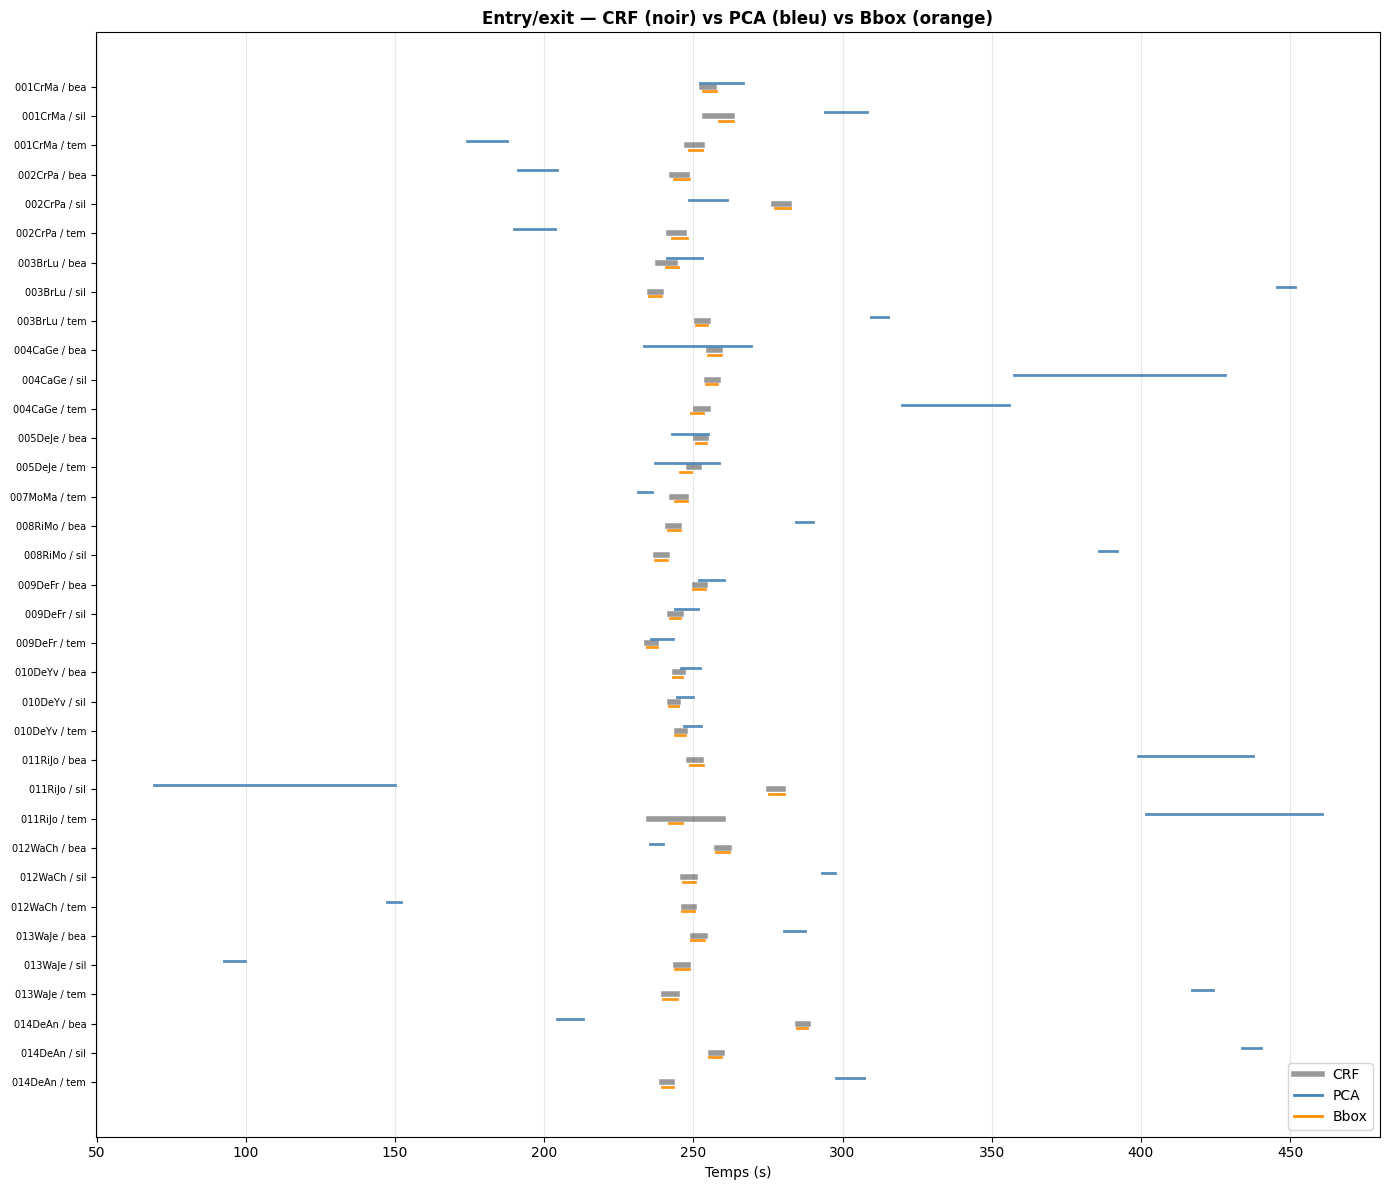

In [11]:
fig, ax = plt.subplots(figsize=(14, 12))

# Sort by participant/condition for readability
df_plot = df_cmp.sort_values(['participant', 'condition']).reset_index(drop=True)
y_positions = np.arange(len(df_plot))

for i, row in df_plot.iterrows():
    y = y_positions[i]
    # CRF (référence)
    if not pd.isna(row['crf_entry']):
        ax.plot([row['crf_entry'], row['crf_exit']], [y, y],
                color='black', linewidth=4, alpha=0.4)
    # PCA
    if not pd.isna(row['entry_pca']):
        ax.plot([row['entry_pca'], row['exit_pca']], [y - 0.15, y - 0.15],
                color='steelblue', linewidth=2, alpha=0.9)
    # Bbox
    if not pd.isna(row['entry_bbox']):
        ax.plot([row['entry_bbox'], row['exit_bbox']], [y + 0.15, y + 0.15],
                color='darkorange', linewidth=2, alpha=0.9)

ax.set_yticks(y_positions)
ax.set_yticklabels([f"{r['participant']} / {r['condition'][:3]}" for _, r in df_plot.iterrows()],
                    fontsize=7)
ax.set_xlabel('Temps (s)')
ax.set_title('Entry/exit — CRF (noir) vs PCA (bleu) vs Bbox (orange)',
              fontweight='bold')
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()

from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], color='black', linewidth=4, alpha=0.4, label='CRF'),
    Line2D([0], [0], color='steelblue', linewidth=2, label='PCA'),
    Line2D([0], [0], color='darkorange', linewidth=2, label='Bbox'),
]
ax.legend(handles=legend_lines, loc='lower right')

plt.tight_layout()
plt.savefig('03c_timelines.png', dpi=80, bbox_inches='tight')
plt.show()

## Export résultats

In [12]:
from pathlib import Path
out_dir = Path(paths.OUTPUTS_DIR) / 'tables'
out_dir.mkdir(parents=True, exist_ok=True)
df_cmp.to_csv(out_dir / '03_sand_detection_comparison.csv', index=False)
print(f"✅ Export : {out_dir / '03_sand_detection_comparison.csv'}")

✅ Export : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\03_sand_detection_comparison.csv


## Synthèse

À remplir après exécution :

| Critère | PCA | Bbox | Verdict |
|---|---|---|---|
| Erreur médiane entry | ... | ... | ... |
| Erreur médiane exit | ... | ... | ... |
| Nb essais |err| > 2s | ... | ... | ... |
| Robustesse occlusions | ... | ... | ... |
| Dépendance CRF | OUI (calibration) | NON | Bbox + simple |

**Choix méthode finale pour la suite (notebook 04/05)** : à décider.

Options possibles :
- Méthode unique (PCA OU bbox)
- Hybride : bbox par défaut, PCA en fallback si bbox échoue
- Méthode unique + utiliser l'autre comme validation croisée